Dataset has 2033 datapoints, and each datapoint has 10 results each.

In [1]:
import itertools

from numpy.f2py.auxfuncs import throw_error
from tqdm.notebook import tqdm
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

failure_probability_delta = 0.49 # When delta is 0.5, and N hits 4 the UCB value has a divide by zero error.

def metadata_extractor(df_smaller):
    metadata = {"number_of_pairs":0,
                "pair_starting_indices":[],
                "pair_number_of_datapoints":[]}
    # preprocessed_df = df[df["predicted_score"]!= -1].copy()
    print("preprocessed_df.shape:", df_smaller.shape)
    current_prompt = ""
    number_of_points = 0
    for index, row in df_smaller.iterrows():
        if current_prompt != row["prompt"]:
            metadata["number_of_pairs"] += 1
            current_prompt = row["prompt"]
            metadata["pair_starting_indices"].append(index)
            metadata["pair_number_of_datapoints"].append(number_of_points)
            number_of_points = 1
        else:
            number_of_points += 1
    metadata["pair_number_of_datapoints"].append(number_of_points)
    metadata["pair_number_of_datapoints"] = metadata["pair_number_of_datapoints"][1:]
    return metadata

def data_reader(filename):
    """
    Reads the data from the json file into a pandas dataset
    :return:
    """
    df = pd.read_json(filename, lines=True)
    df.drop(df.index[~(df['predicted_score'] != -1)], inplace= True)
    df.reset_index(drop=True, inplace=True)
    # filtered_df = df[df["predicted_score"]!= -1]
    print("filtered_df.shape:", df.shape)
    return df, metadata_extractor(df)

class UCB:
    """
    Class that holds all the variables and runs the required algorithms.
    """
    def __init__(self, df, metadata):
        self.metadata = metadata
        self.dataframe = df
        self.n_pairs = metadata["number_of_pairs"] # total number of pairs
        self.llm_emperical_averages = [0.0] * self.n_pairs
        for pair in range(metadata["number_of_pairs"]):
            self.llm_emperical_averages[pair] = np.array(
                df.iloc[metadata["pair_starting_indices"][pair]:
                        metadata["pair_starting_indices"][pair]+metadata["pair_number_of_datapoints"][pair]]["predicted_score"]).mean()
        self.reset_algo()

    def reset_algo(self):
        """
        Resets the required variables to start running the learning algorithm.
        """
        self.responses = [np.empty(0) for _ in range(self.n_pairs)]          # Number of times each arm was pulled
        self.ground_truth_variances = [0.0] * self.n_pairs
        self.ground_truth_variance_sum = 0
        for pair in range(self.n_pairs): # precompute all the ground truth variances.
            self.ground_truth_variances[pair] = self.get_ground_truth_variance(pair)
            self.ground_truth_variance_sum += self.ground_truth_variances[pair]

    def select_pair(self, selection_method = "ucb"):
        """
        Chooses the next pair to start questioning based on the chosen method.
        Uses a weighted method of choosing the best response for ucb and ground_variance. Also has a max_ucb that just chooses the pair with the highest variance upper bound.
        :param selection_method: "ucb", "ground_variance"
        """
        # If any pair hasn't been tried 4log(1/\delta), try it first
        for pair in range(self.n_pairs):
            if self.responses[pair].shape[0] < 1:
                return pair

        if selection_method == "max_ucb":
            selection_criteria_values = [0.0] * self.n_pairs
            for pair in range(self.n_pairs):
                if self.responses[pair].shape[0] < math.log(1/failure_probability_delta,2)*4: # Minimum N from the condition.
                    return pair
            for pair in range(self.n_pairs):
                selection_criteria_values[pair] = self.get_ucb_value(pair)#/Number of arm pulls.
            return selection_criteria_values.index(max(selection_criteria_values))


        if selection_method == "ucb":
            selection_criteria_values = [0.0] * self.n_pairs
            selection_criteria_sum = 0
            for pair in range(self.n_pairs):
                selection_criteria_values[pair] = self.get_ucb_value(pair)
                selection_criteria_sum += selection_criteria_values[pair]
            return np.random.choice(len(selection_criteria_values), p=selection_criteria_values / selection_criteria_sum)

        # if selection_method == "sample_variance": # todo need to make this work.


        if selection_method == "ground_variance":
            return np.random.choice(len(self.ground_truth_variances), p=self.ground_truth_variances / self.ground_truth_variance_sum)


    def get_pair_information(self, pair, information):
        """
        Helper function to get any required information about a pair.
        It also gives the next_predicted score to fake data being present.
        :param pair:
        :param information:
        :return:
        """
        if information == "next_predicted_score":
            try:
                return self.dataframe.iloc[self.metadata["pair_starting_indices"][pair]
                    +np.random.randint(self.metadata["pair_number_of_datapoints"][pair])]["predicted_score"]
            except:
                print("error pair:", pair)
                raise
        elif information == "llm_average_score":
            return self.llm_emperical_averages[pair]

    def get_ground_truth_variance(self, pair):
        """
        Gets the ground truth variance of the judge LLM of the pair by taking \Sum_{i=1}^{10}{(sample_i - mean_score)^2}/10
        :param pair:
        :return: the ground truth variance of the pair in question.
        """
        ground_truth_var = np.square(np.array(self.dataframe.iloc[self.metadata["pair_starting_indices"][pair]:self.metadata["pair_starting_indices"][pair]+self.metadata["pair_number_of_datapoints"][pair]]["predicted_score"]) - np.array(self.dataframe.iloc[self.metadata["pair_starting_indices"][pair]:self.metadata["pair_starting_indices"][pair]+self.metadata["pair_number_of_datapoints"][pair]]["predicted_score"]).mean()).sum()/self.metadata["pair_number_of_datapoints"][pair]
        return ground_truth_var

    def get_ucb_value(self, pair_number):
        """
        Gets the ground truth variance of the judge LLM of the pair by taking \Sum_{i=1}^{10}{(sample_i - mean_score)^2}/10
        :param pair_number:
        :return:
        """
        return self.get_sample_covariance(self.responses[pair_number])/(1-(2*math.sqrt(math.log(1/failure_probability_delta,2)/(self.responses[pair_number].shape[0]))))

    def get_sample_covariance(self, selected_pair_responses):
        """
        Gets the sample variance of the judge LLM of the pair by taking \Sum_{i=1}^{n(t)}{(sample_i - total_sample_mean_score)^2}/(n(t) - 1)
        :param pair:
        :return: the sample variance of the pair in question.
        """
        return np.square(selected_pair_responses-selected_pair_responses.mean()).sum()/(selected_pair_responses.shape[0]-1)

    def get_all_sample_covariance(self):
        """
        Calculates sample variances of each datapoint pair.
        :return: all the sample variances of the datapoint pairs as an array.
        """
        to_return = []
        for pair in range(self.n_pairs):
            to_return.append(self.get_sample_covariance(self.responses[pair]))
        to_return = np.array(to_return)
        return to_return

    def update(self, chosen_pair):
        """
        Pseudo-queries a new pair's value in total and updates it to the list of responses that the pair got so far.
        Updates the responses list is place.
        :param chosen_pair: pair to be updated.
        """
        new_value = self.get_pair_information(chosen_pair, information="next_predicted_score")
        clipped_new_value = max(min(new_value, 5), 0)
        self.responses[chosen_pair] = np.append(self.responses[chosen_pair], clipped_new_value)

    def get_total_error(self, type = "squared_error"): # change human score to emperical mean.
        total_error = 0
        if type == "squared_error":
            for pair in range(self.n_pairs):
                total_error += (self.get_pair_information(pair, "llm_average_score") - self.responses[pair].mean())**2
        return total_error

    def run_algo_uniform(self, number_of_queries, error_type = "squared_error"):
        self.reset_algo()
        total_errors = []
        for iteration in tqdm(range(int(number_of_queries))):
            pair_number = iteration%self.n_pairs
            algorithm.update(pair_number)
            if  iteration > self.n_pairs and iteration % 100 == 0:
                total_errors.append(self.get_total_error(error_type))
        return total_errors

    def run_algo_UCB(self, number_of_queries, error_type = "squared_error"):
        self.reset_algo()
        total_errors = []
        for iteration in tqdm(range(int(number_of_queries))):
            if iteration <= self.n_pairs*(1+(math.log(1/failure_probability_delta,2)*4)): #allowing for round robin before burn in period. The +1 is needed because we want to accound for the threshold being 4.1, and iteration being at 4.1*number of pairs, but the rest of the dataset has only had 4 evaluations.
                most_uncertain_pair = iteration%self.n_pairs
            else:
                most_uncertain_pair = algorithm.select_pair(selection_method = "ucb")
            if most_uncertain_pair is None:
                raise
            if iteration > self.n_pairs and iteration % 100 == 0:
                total_errors.append(self.get_total_error(error_type))
            algorithm.update(most_uncertain_pair)
        return total_errors

    def run_algo_ground_truth_var(self, number_of_queries, error_type = "squared_error"):
        self.reset_algo()
        total_errors = []
        for iteration in tqdm(range(int(number_of_queries))):
            chosen_pair = algorithm.select_pair(selection_method = "ground_variance")
            if iteration > self.n_pairs and iteration % 100 == 0:
                total_errors.append(self.get_total_error(error_type))
            algorithm.update(chosen_pair)
        return total_errors

# Running Multiple Files

In [2]:
files = ["data/helpsteer2.jsonl","data/helpsteer2_complexity.jsonl","data/helpsteer2_correctness.jsonl","data/helpsteer2_helpfulness.jsonl","data/helpsteer2_verbosity.jsonl"]
number_of_queries_per_pair = 30
# First file is the old data (not many samples)

filtered_df.shape: (28264, 5)
preprocessed_df.shape: (28264, 5)


  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

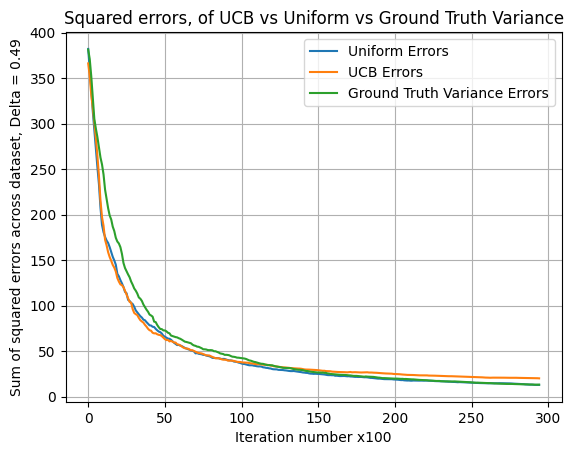

In [3]:
df, metadata = data_reader(files[1])
algorithm = UCB(df, metadata)
number_of_queries = metadata["number_of_pairs"]*number_of_queries_per_pair

uniform_errors = algorithm.run_algo_uniform(number_of_queries=number_of_queries)
UCB_errors = algorithm.run_algo_UCB(number_of_queries=number_of_queries)
ground_truth_variance_errors = algorithm.run_algo_ground_truth_var(number_of_queries=number_of_queries)
plt.plot(uniform_errors, label='Uniform Errors')
plt.plot(UCB_errors, label='UCB Errors')
plt.plot(ground_truth_variance_errors, label='Ground Truth Variance Errors')
plt.title('Squared errors, of UCB vs Uniform vs Ground Truth Variance')
plt.xlabel('Iteration number x100')
plt.ylabel(f'Sum of squared errors across dataset, Delta = {failure_probability_delta}')
plt.legend()
plt.grid(True)
plt.show()

filtered_df.shape: (29011, 5)
preprocessed_df.shape: (29011, 5)


  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

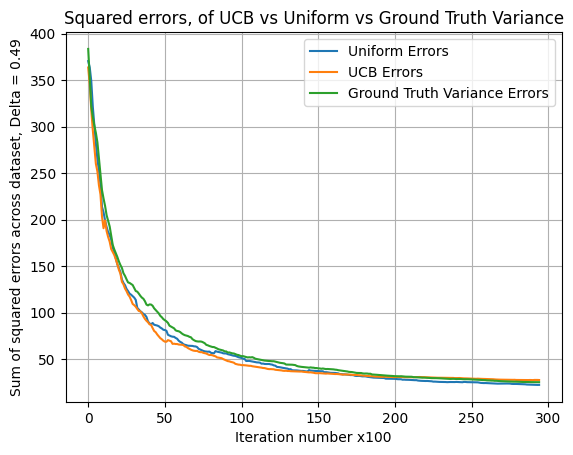

In [4]:
df, metadata = data_reader(files[2])
algorithm = UCB(df, metadata)
number_of_queries = metadata["number_of_pairs"]*number_of_queries_per_pair

uniform_errors = algorithm.run_algo_uniform(number_of_queries=number_of_queries)
UCB_errors = algorithm.run_algo_UCB(number_of_queries=number_of_queries)
ground_truth_variance_errors = algorithm.run_algo_ground_truth_var(number_of_queries=number_of_queries)
plt.plot(uniform_errors, label='Uniform Errors')
plt.plot(UCB_errors, label='UCB Errors')
plt.plot(ground_truth_variance_errors, label='Ground Truth Variance Errors')
plt.title('Squared errors, of UCB vs Uniform vs Ground Truth Variance')
plt.xlabel('Iteration number x100')
plt.ylabel(f'Sum of squared errors across dataset, Delta = {failure_probability_delta}')
plt.legend()
plt.grid(True)
plt.show()

filtered_df.shape: (29729, 5)
preprocessed_df.shape: (29729, 5)


  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

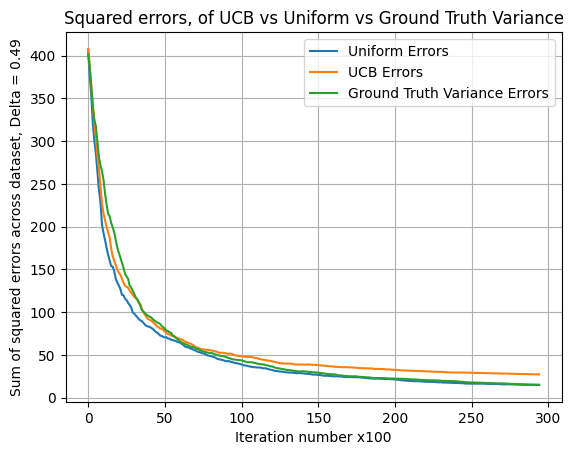

In [5]:
df, metadata = data_reader(files[3])
algorithm = UCB(df, metadata)
number_of_queries = metadata["number_of_pairs"]*number_of_queries_per_pair

uniform_errors = algorithm.run_algo_uniform(number_of_queries=number_of_queries)
UCB_errors = algorithm.run_algo_UCB(number_of_queries=number_of_queries)
ground_truth_variance_errors = algorithm.run_algo_ground_truth_var(number_of_queries=number_of_queries)
plt.plot(uniform_errors, label='Uniform Errors')
plt.plot(UCB_errors, label='UCB Errors')
plt.plot(ground_truth_variance_errors, label='Ground Truth Variance Errors')
plt.title('Squared errors, of UCB vs Uniform vs Ground Truth Variance')
plt.xlabel('Iteration number x100')
plt.ylabel(f'Sum of squared errors across dataset, Delta = {failure_probability_delta}')
plt.legend()
plt.grid(True)
plt.show()

filtered_df.shape: (29232, 5)
preprocessed_df.shape: (29232, 5)


  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

  0%|          | 0/30510 [00:00<?, ?it/s]

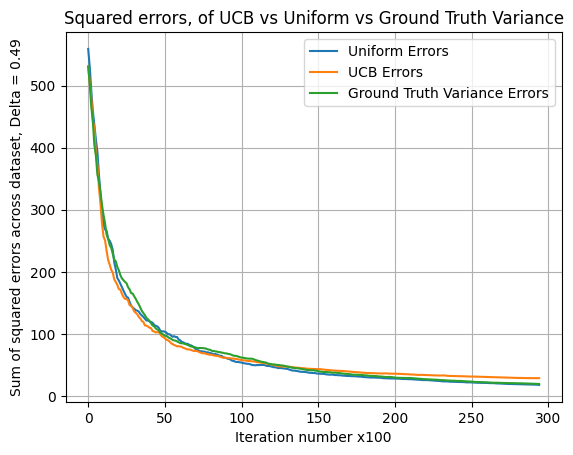

In [6]:
df, metadata = data_reader(files[4])
algorithm = UCB(df, metadata)
number_of_queries = metadata["number_of_pairs"]*number_of_queries_per_pair

uniform_errors = algorithm.run_algo_uniform(number_of_queries=number_of_queries)
UCB_errors = algorithm.run_algo_UCB(number_of_queries=number_of_queries)
ground_truth_variance_errors = algorithm.run_algo_ground_truth_var(number_of_queries=number_of_queries)
plt.plot(uniform_errors, label='Uniform Errors')
plt.plot(UCB_errors, label='UCB Errors')
plt.plot(ground_truth_variance_errors, label='Ground Truth Variance Errors')
plt.title('Squared errors, of UCB vs Uniform vs Ground Truth Variance')
plt.xlabel('Iteration number x100')
plt.ylabel(f'Sum of squared errors across dataset, Delta = {failure_probability_delta}')
plt.legend()
plt.grid(True)
plt.show()

# Data Exploration to preprocess

In [ ]:
smaller_temp = temp[temp["predicted_score"] != -1]
print(smaller_temp.shape)

In [ ]:
files = ["data/helpsteer2.jsonl","data/helpsteer2_complexity.jsonl","data/helpsteer2_correctness.jsonl","data/helpsteer2_helpfulness.jsonl","data/helpsteer2_verbosity.jsonl"]
temp = pd.read_json(files[1], lines=True)
# data_metadata = {}
print(temp.shape)
print(sum(temp["predicted_score"] == -1))
arr = temp["prompt"].unique()
print(range(len(arr)))
for index,ele in enumerate(arr):
    print(index,":\t",ele)

# Debugging

In [4]:
algorithm.n_pairs

1017

In [6]:
pair = 1000
algorithm.get_ucb_value(pair) # Don't let this be negative.

np.float64(1.5531875334441059)

In [14]:
algorithm.dataframe.iloc[algorithm.metadata["pair_starting_indices"][pair]]

prompt             provide bullet points on the various sections ...
response           In that case, I would recommend including the ...
human_score                                                        1
rationale          The response suggests including the following ...
predicted_score                                                    4
Name: 27804, dtype: object

In [ ]:
print(algorithm.responses[pair])
print(algorithm.get_sample_covariance(algorithm.responses[pair]))
print(metadata["pair_starting_indices"][1016])
print(metadata["pair_number_of_datapoints"][1016])
print((1-(2*math.sqrt(math.log(1/failure_probability_delta,2)/(algorithm.responses[pair].shape[0]+1)))))

In [ ]:
pair_number = 1
print("algorithm.responses[pair_number]:",algorithm.responses[pair_number])
print("algorithm.responses[pair_number].shape[0]", algorithm.responses[pair_number].shape[0])
print("(1-(2*math.sqrt(math.log(1/failure_probability_delta,2)/algorithm.responses[pair_number].shape[0])))", (2*math.sqrt(math.log(1/failure_probability_delta,2)/algorithm.responses[pair_number].shape[0])))
algorithm.get_sample_covariance(algorithm.responses[pair_number])/(1-(2*math.sqrt(math.log(1/failure_probability_delta,2)/algorithm.responses[pair_number].shape[0])))